In [6]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [7]:
import preprocess
from clean import DataCleaner

In [8]:
df = pd.read_csv('data/bike_hour.csv')

In [9]:
cleaner = DataCleaner(df)
df = cleaner.clean()

In [10]:
df.info()

<class 'pandas.DataFrame'>
Index: 17357 entries, 0 to 17378
Data columns (total 14 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   dteday      17357 non-null  str    
 1   season      17357 non-null  int64  
 2   yr          17357 non-null  int64  
 3   mnth        17357 non-null  int64  
 4   hr          17357 non-null  int64  
 5   holiday     17357 non-null  int64  
 6   weekday     17357 non-null  int64  
 7   workingday  17357 non-null  int64  
 8   weathersit  17357 non-null  int64  
 9   temp        17357 non-null  float64
 10  atemp       17357 non-null  float64
 11  hum         17357 non-null  float64
 12  windspeed   17357 non-null  float64
 13  cnt         17357 non-null  int64  
dtypes: float64(4), int64(9), str(1)
memory usage: 2.0 MB


### Plan
firstly, convert the normalized weather columns back to real units and the date str -> datetime

then, perform eda on these features to confirm selection:
- hr, mnth, weekday, workingday, holiday, weathersit, temp, hum, windspeed, yr -> 10 total

features to leave out:
- casual, registered -> they add up to cnt (leakage), already removed in cleaning
- atemp -> almost the same as temp, check the correlation to confirm
- season -> should be covered by month, check to confirm

cnt (rentals per hour) is our target value

In [11]:
df = preprocess.convert_date(df)
df = preprocess.convert_weather_units(df)

In [12]:
df.head(3)

,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,cnt
0,2011-01-01,1,0,1,0,0,6,0,1,9.84,14.395,81.0,0.0,16
1,2011-01-01,1,0,1,1,0,6,0,1,9.02,13.635,80.0,0.0,40
2,2011-01-01,1,0,1,2,0,6,0,1,9.02,13.635,80.0,0.0,32


### Plans for Models to use

1. Linear Regression
2. Random Forest
3. Gradient Boosting -> HistGradientBoosting

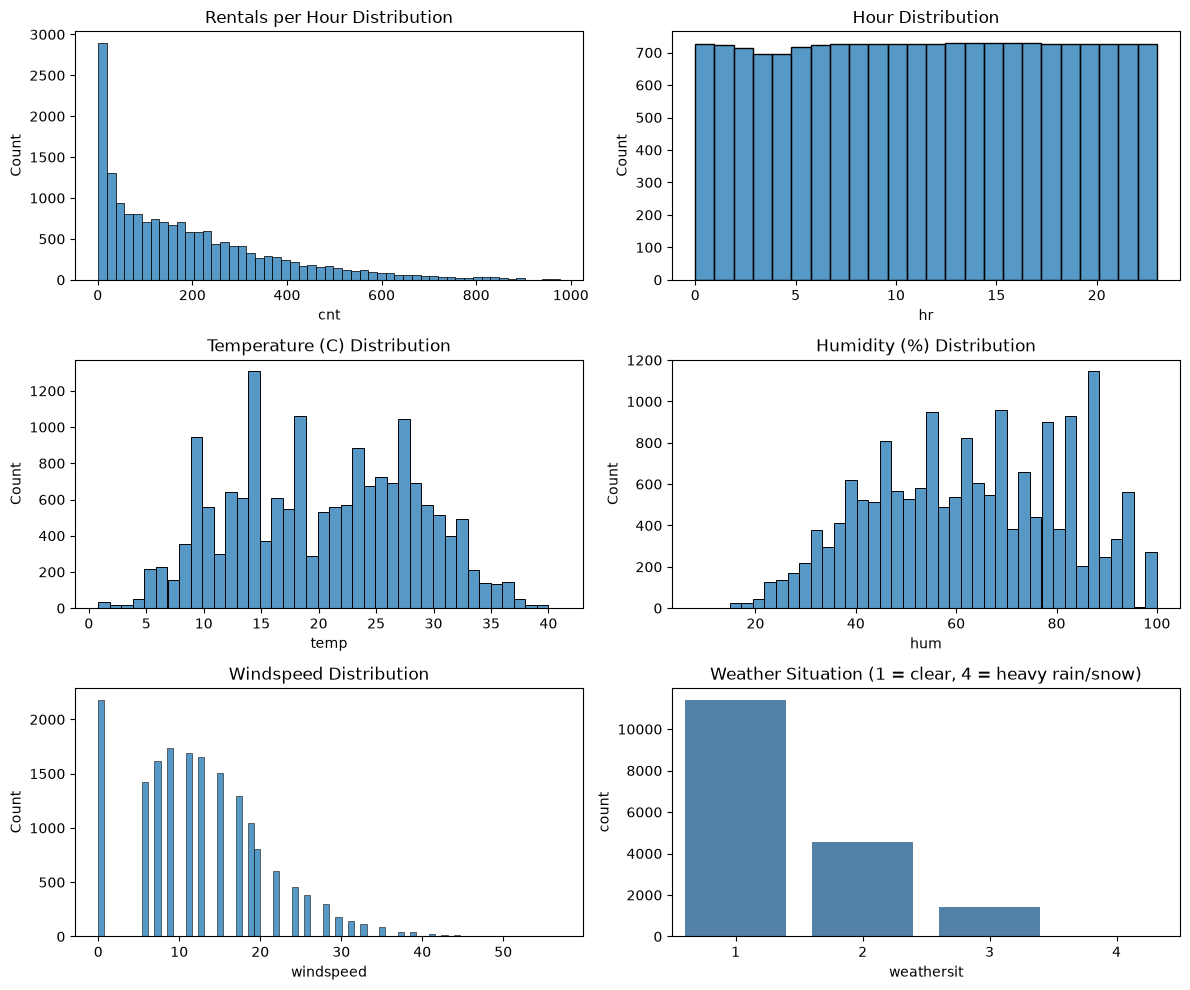

In [13]:
# Create a 3x2 grid (3 rows, 2 columns)
fig, axes = plt.subplots(3, 2, figsize=(12, 10))

# cnt (target)
sns.histplot(df, x=df['cnt'], ax=axes[0][0])
axes[0][0].set_title("Rentals per Hour Distribution")

# hr
sns.histplot(df, x=df['hr'], bins=24, ax=axes[0][1])
axes[0][1].set_title("Hour Distribution")

# temp
sns.histplot(df, x=df['temp'], ax=axes[1][0])
axes[1][0].set_title("Temperature (C) Distribution")

# hum
sns.histplot(df, x=df['hum'], ax=axes[1][1])
axes[1][1].set_title("Humidity (%) Distribution")

# windspeed
sns.histplot(df, x=df['windspeed'], ax=axes[2][0])
axes[2][0].set_title("Windspeed Distribution")

# weathersit
sns.countplot(df, x=df['weathersit'], ax=axes[2][1], color="steelblue")
axes[2][1].set_title("Weather Situation (1 = clear, 4 = heavy rain/snow)")

# Adjust spacing and display
plt.tight_layout()
plt.show()

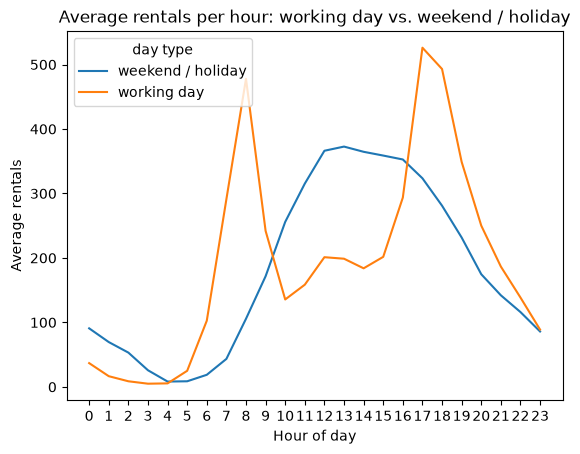

In [14]:
# The hourly pattern is the strongest thing we expect to see, split by working day
hourly = df.groupby(["hr", "workingday"])["cnt"].mean().reset_index()
hourly["day type"] = hourly["workingday"].map({0: "weekend / holiday", 1: "working day"})

sns.lineplot(data=hourly, x="hr", y="cnt", hue="day type")
plt.xticks(range(0, 24))
plt.xlabel("Hour of day")
plt.ylabel("Average rentals")
plt.title("Average rentals per hour: working day vs. weekend / holiday")
plt.show()

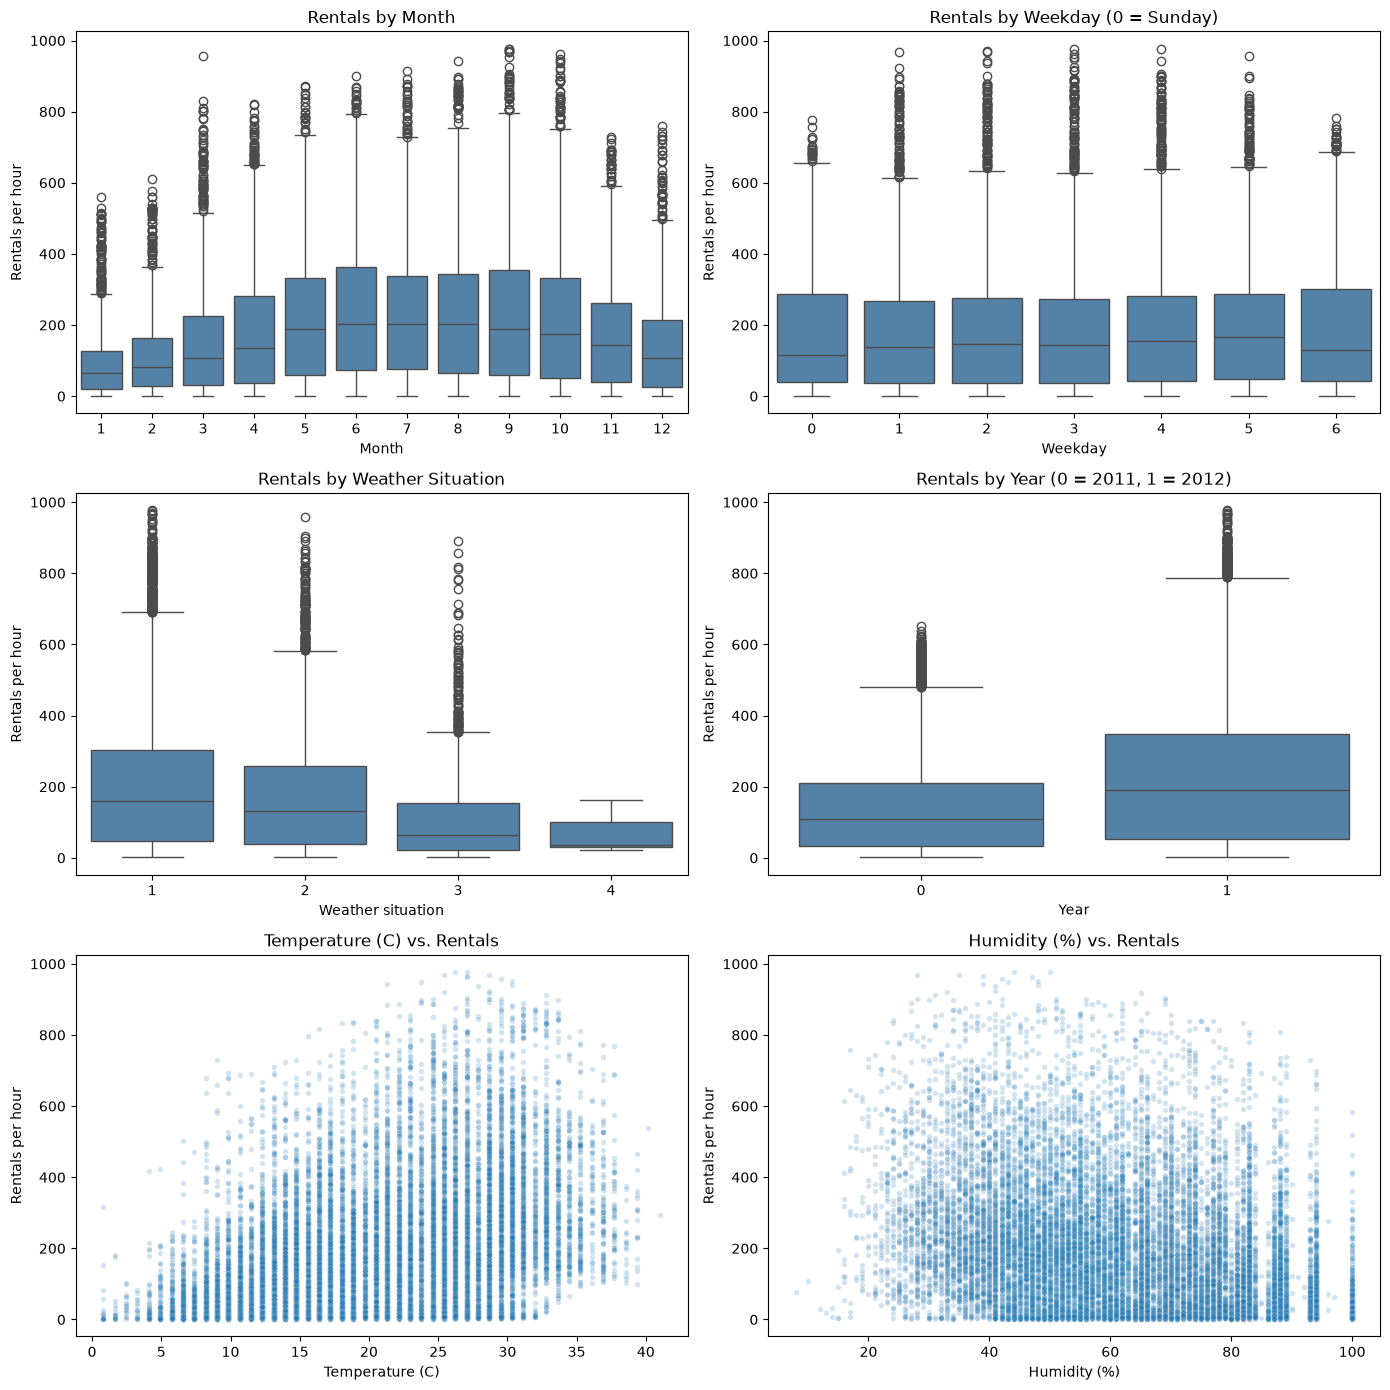

In [15]:
# Compare rentals with each feature using the current df
plot_df = df.copy()

fig, axes = plt.subplots(3, 2, figsize=(14, 14))

sns.boxplot(data=plot_df, x="mnth", y="cnt", ax=axes[0, 0], color="steelblue")
axes[0, 0].set_title("Rentals by Month")
axes[0, 0].set_xlabel("Month")

sns.boxplot(data=plot_df, x="weekday", y="cnt", ax=axes[0, 1], color="steelblue")
axes[0, 1].set_title("Rentals by Weekday (0 = Sunday)")
axes[0, 1].set_xlabel("Weekday")

sns.boxplot(data=plot_df, x="weathersit", y="cnt", ax=axes[1, 0], color="steelblue")
axes[1, 0].set_title("Rentals by Weather Situation")
axes[1, 0].set_xlabel("Weather situation")

sns.boxplot(data=plot_df, x="yr", y="cnt", ax=axes[1, 1], color="steelblue")
axes[1, 1].set_title("Rentals by Year (0 = 2011, 1 = 2012)")
axes[1, 1].set_xlabel("Year")

for ax, column, label in [
    (axes[2, 0], "temp", "Temperature (C)"),
    (axes[2, 1], "hum", "Humidity (%)")
]:
    sns.scatterplot(x=plot_df[column], y=plot_df["cnt"],
                    alpha=0.2, s=15, ax=ax)
    ax.set_xlabel(label)
    ax.set_title(f"{label} vs. Rentals")

for ax in axes.flat:
    ax.set_ylabel("Rentals per hour")

plt.tight_layout()
plt.show()

In [16]:
# Counts help distinguish well-supported patterns from small groups
print("Weather situation summaries (4 is very rare)")
display(plot_df.groupby("weathersit")["cnt"]
        .agg(["count", "mean", "median", "std"]).round(2))

print("Weekday summaries (0 = Sunday)")
display(plot_df.groupby("weekday")["cnt"]
        .agg(["count", "mean", "median", "std"]).round(2))

print("Holiday summaries")
display(plot_df.groupby("holiday")["cnt"]
        .agg(["count", "mean", "median", "std"]).round(2))

print("Year summaries")
display(plot_df.groupby("yr")["cnt"]
        .agg(["count", "mean", "median", "std"]).round(2))

Weather situation summaries (4 is very rare)


,count,mean,median,std
weathersit,,,,
1,11413,204.87,159.0,189.49
2,4542,175.21,133.0,165.45
3,1399,112.83,65.0,134.30
4,3,74.33,36.0,77.93


Weekday summaries (0 = Sunday)


,count,mean,median,std
weekday,,,,
0,2502,177.47,116.0,168.17
1,2479,183.74,139.0,179.51
2,2453,191.24,147.0,187.82
3,2475,191.13,143.0,190.89
4,2449,197.95,155.0,188.16
5,2487,196.14,165.0,174.08
6,2512,190.21,129.0,179.82


Holiday summaries


,count,mean,median,std
holiday,,,,
0,16857,190.64,144.0,182.00
1,500,156.87,97.0,156.76


Year summaries


,count,mean,median,std
yr,,,,
0,8623,144.09,110.0,133.83
1,8734,234.67,191.0,208.91


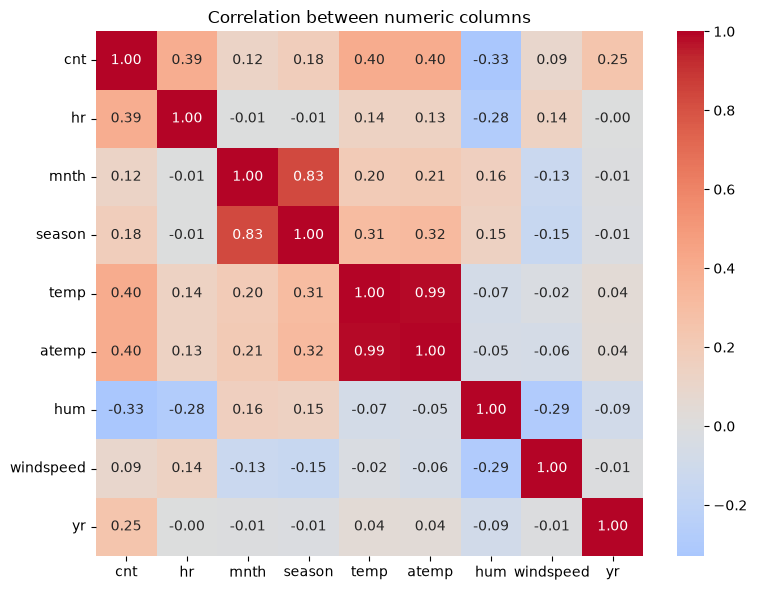

In [17]:
# Correlation of the numeric columns, season and atemp included to confirm dropping them
numeric_cols = ["cnt", "hr", "mnth", "season", "temp", "atemp", "hum", "windspeed", "yr"]

plt.figure(figsize=(8, 6))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation between numeric columns")
plt.tight_layout()
plt.show()

In [18]:
df['temp'].corr(df["cnt"])

np.float64(0.4044225170705614)

In [19]:
df['hum'].corr(df['cnt'])

np.float64(-0.32895064233429905)

In [20]:
# windspeed has only ~30 distinct values and a lot of exact zeros, check if zeros behave differently
df.groupby(df['windspeed'] == 0)['cnt'].agg(["count", "mean"]).round(2)

,count,mean
windspeed,,
False,15177,193.84
True,2180,160.64


## Findings

1. Hour of the day is the strongest pattern, but it flips by day type -- working days have two peaks (8am and 5-6pm, commuting) while weekends have one wide peak around midday. A single hour-vs-rentals line (what linear regression can learn) will miss this, need an hour x workingday interaction (trees get it for free)
2. Temperature has the clearest trend (corr ~0.40), rentals go from ~70/hr below 10C to ~330/hr above 30C. Humidity is negative (~-0.33), windspeed is almost flat (~0.09)
3. Weather situation drops rentals as it gets worse (clear ~205, mist ~175, light rain/snow ~113). Situation 4 has only 3 rows so its average (74) means nothing
4. 2012 has far more rentals than 2011 (~235 vs ~144 per hour) -- system growth, so `yr` has to be kept, it is also the reason a time-based split is harder than a random one
5. Month shows a smooth summer peak (jun-sep) and a winter low, season is ~0.83 correlated with month so it is dropped. atemp is ~0.99 correlated with temp so it is dropped as well
6. Weekday on its own is almost flat (177-198 average), the difference is in the hourly shape not the total. Holidays are lower (157 vs 191)
7. Rentals (cnt) are right skewed (skew ~1.3) with a long tail up to ~970, so the biggest errors will come from the rush hours
8. Windspeed has 2180 exact zeros (~12%) and only ~30 distinct values, looks like low readings rounded down / missing readings recorded as 0. Those hours have fewer rentals (161 vs 194) but it is not clearly a data error, so they are kept
9. The data has 165 missing hours (17,379 rows against 17,544 hours in two years), irrelevant here since no lag features are used, but it would matter for forecasting with previous hours
